
=== DataFrame ===
  CustomerID        Name                  Email OrderID   OrderDate ProductID  \
0        001    John Doe    johndoe@example.com    1001  2025-01-01      P001   
1        001    John Doe    johndoe@example.com    1001  2025-01-01      P002   
2        001    John Doe    johndoe@example.com    1002  2025-01-05      P003   
3        002  Jane Smith  janesmith@example.com    1003  2025-01-07      P004   

  ProductName   Price  Quantity   Total  
0      Laptop  1200.0         1  1200.0  
1       Mouse    25.0         2    50.0  
2     Monitor   300.0         1   300.0  
3      Tablet   500.0         1   500.0  

=== Total Revenue per Customer ===
Name
Jane Smith     500.0
John Doe      1550.0
Name: Total, dtype: float64

=== Top Products by Revenue ===
ProductName
Laptop     1200.0
Tablet      500.0
Monitor     300.0
Mouse        50.0
Name: Total, dtype: float64


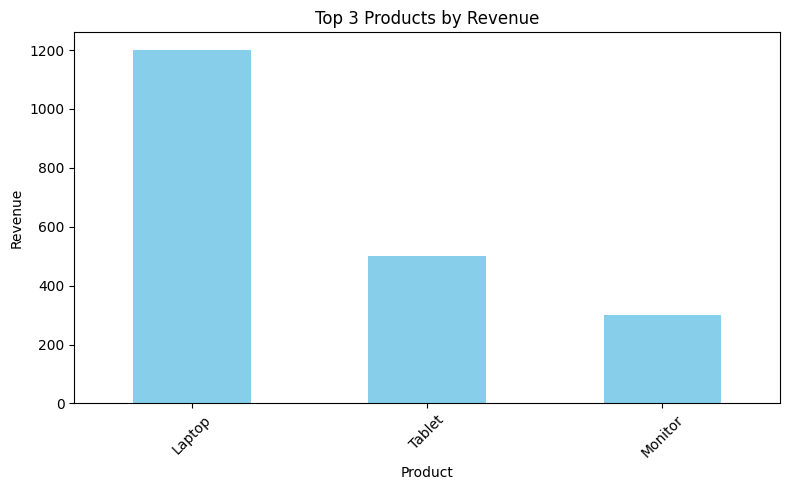


Data saved to customers_orders_output.csv


In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Parse XML
# =========================
tree = ET.parse("customers_orders.xml")
root = tree.getroot()

data = []

for customer in root.findall("Customer"):
    customer_id = customer.find("CustomerID").text
    name = customer.find("Name").text
    email = customer.find("Email").text

    for order in customer.find("Orders").findall("Order"):
        order_id = order.find("OrderID").text
        order_date = order.find("OrderDate").text

        for item in order.find("Items").findall("Item"):
            product_id = item.find("ProductID").text
            product_name = item.find("ProductName").text
            price = float(item.find("Price").text)
            quantity = int(item.find("Quantity").text)

            total = price * quantity

            data.append([
                customer_id, name, email,
                order_id, order_date,
                product_id, product_name,
                price, quantity, total
            ])

# =========================
# 2. Create DataFrame
# =========================
df = pd.DataFrame(data, columns=[
    "CustomerID", "Name", "Email",
    "OrderID", "OrderDate",
    "ProductID", "ProductName",
    "Price", "Quantity", "Total"
])

print("\n=== DataFrame ===")
print(df)

# =========================
# 3. Revenue per Customer
# =========================
customer_revenue = df.groupby("Name")["Total"].sum()

print("\n=== Total Revenue per Customer ===")
print(customer_revenue)

# =========================
# 4. Top Products
# =========================
product_revenue = df.groupby("ProductName")["Total"].sum().sort_values(ascending=False)

print("\n=== Top Products by Revenue ===")
print(product_revenue)

# =========================
# 5. Visualization
# =========================
top3 = product_revenue.head(3)

plt.figure(figsize=(8,5))
top3.plot(kind="bar", color="skyblue")

plt.title("Top 3 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =========================
# 6. Save to CSV
# =========================
df.to_csv("customers_orders_output.csv", index=False)

print("\nData saved to customers_orders_output.csv")